# Simple PDF to MCQ Generator
This notebook explains how to create MCQ questions from a PDF using the Groq API and Llama model.

## Step 1: Install Libraries

In [ ]:
# Run this once
!pip install groq pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 26.7 MB/s eta 0:00:00


## Step 2: Import Libraries

In [ ]:
import pdfplumber
from groq import Groq

## Step 3: Add Your Groq API Key

Get API key from: https://console.groq.com

In [ ]:
client = Groq(
    api_key='groq'
)

## Step 4: Read Text from PDF

In [ ]:
def extract_text_from_pdf(pdf_path):
    text = ''

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()

            if page_text:
                text += page_text + '\n'

    return text

## Step 5: Load Your PDF

In [ ]:
# Change file name if needed
pdf_path = '/content/budget_speech.pdf'

pdf_text = extract_text_from_pdf(pdf_path)

print(pdf_text[:1000])

GOVERNMENT OF INDIA
BUDGET 2026-2027
SPEECH
OF
NIRMALA SITHARAMAN
MINISTER OF FINANCE
February 1, 2026
CONTENTS
Page No.
Introduction 1
PART - A
Yuva Shakti and 3 kartavya 2
Reform Express 3
First kartavya: to accelerate and sustain economic growth 3
Second kartavya: fulfil aspirations and build capacity 10
Third kartavya: Sabka Sath, Sabka Vikas 14
16th Finance Commission 18
Fiscal Consolidation 18
PART – B
Direct taxes 20
Indirect Taxes 26
Annexure to Part-A 32
Annexure to Part-B
Amendments relating to Direct Taxes 33
Amendments relating to Indirect Taxes 50
Budget 2026-2027
Speech of
Nirmala Sitharaman
Minister of Finance
February 1, 2026
Hon’ble Speaker,
On the sacred occasion of Magha Purnima and the birth
anniversary of Guru Ravidas, I present the Budget for the year 2026-2027.
Introduction
1. Since we assumed office 12 years ago, India’s economic trajectory
has been marked by stability, fiscal discipline, sustained growth and
moderate inflation. This is the result of conscious c

## Step 6: Generate MCQs Using LLM

In [ ]:
def generate_mcqs(text):

    prompt = f'''
    Generate 10 MCQ questions from the text.

    Rules:
    - Each question should have 4 options

    - Keep questions simple
    - Avoid duplicate questions

    Text:
    {text[:5000]}
    '''

    #- Mention correct answer

    response = client.chat.completions.create(
        model='llama-3.3-70b-versatile',
        messages=[
            {
                'role': 'system',
                'content': 'You are a helpful MCQ generator.'
            },
            {
                'role': 'user',
                'content': prompt
            }
        ],
        temperature=0.5,
        max_tokens=2000
    )

    return response.choices[0].message.content

In [ ]:
'''def generate_mcqs(text):

    prompt = f'''
    Generate 10 MCQ questions from the text.

    Rules:
    - Each question should have 4 options

    - Keep questions simple
    - Avoid duplicate questions

    Text:
    {text[:5000]}
    '''

    #- Mention correct answer?

    response = client.chat.completions.create(
        model='llama-3.3-70b-versatile',
        messages=[

    {
        "role": "system",
        "content": "You are an expert MCQ teacher."
    },

    {
        "role": "user",
        "content": "Generate one MCQ from AI topic."
    },

    {
        "role": "assistant",
        "content": """
        1. What is AI?

        A) Animal
        B) Artificial Intelligence
        C) Database
        D) Network

        Correct Answer: B) Artificial Intelligence
        """
    },

    {
        "role": "user",
        "content": "Generate another MCQ from Machine Learning."
    }

],
        temperature=0.5,
        max_tokens=2000
    )

    return response.choices[0].message.content

IndentationError: unexpected indent (303741805.py, line 4)

## Step 7: Generate Questions

In [ ]:
mcqs = generate_mcqs(pdf_text)

print(mcqs)

Here are 10 MCQ questions based on the text:

1. Who presented the Budget for the year 2026-2027?
A) Nirmala Sitharaman
B) Hon'ble Prime Minister Modi
C) Guru Ravidas
D) Finance Minister of India

Answer: A) Nirmala Sitharaman

2. What is the name of the approach inspired by 3 kartavya mentioned in the Budget?
A) Yuva Shakti
B) Sankalp
C) Kartavya Bhawan
D) Viksit Bharat

Answer: B) Sankalp

3. What is the first kartavya mentioned in the Budget?
A) To accelerate and sustain economic growth
B) To fulfil aspirations of the people
C) To ensure access to resources and amenities
D) To reduce critical import dependencies

Answer: A) To accelerate and sustain economic growth

4. What is the name of the dialogue where innovative ideas were shared with the Prime Minister?
A) Viksit Bharat Young Leaders Dialogue 2026
B) Yuva Shakti Dialogue
C) Sankalp Dialogue
D) Kartavya Bhawan Dialogue

Answer: A) Viksit Bharat Young Leaders Dialogue 2026

5. What is the vision of the Government mentioned in t

## Step 8: Save MCQs into TXT File

In [ ]:
'''with open('mcqs.txt', 'w', encoding='utf-8') as file:
    file.write(mcqs)

print('MCQs saved successfully')

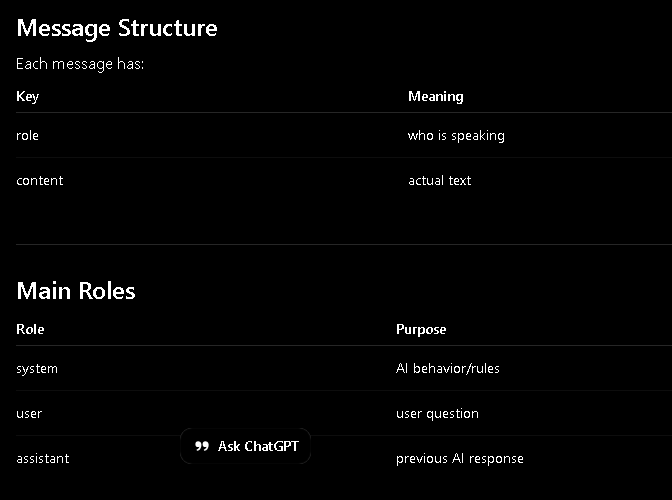

 messages=[
  
            {
                'role': 'system',
                'content': 'You are a helpful MCQ generator.'
            },
            {
                'role': 'user',
                'content': prompt
            }
        ],

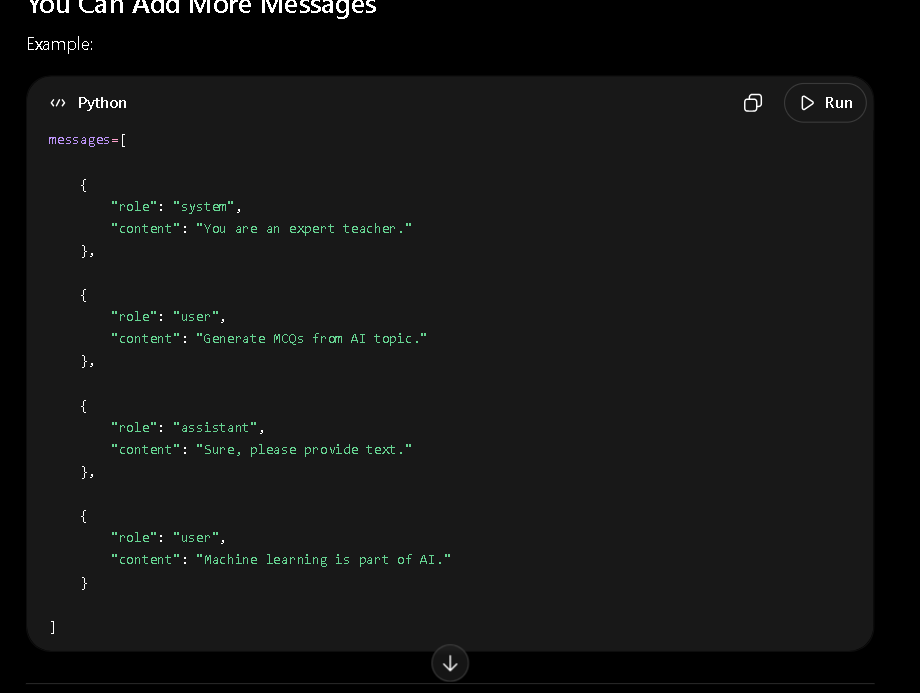